**Senior Living Care Delivery & Response Time Analysis**

**Introduction**

In senior living facilities, timely responses to resident care requests are essential for maintaining quality of care, resident satisfaction, and operational efficiency. Caregivers may experience periods of increased demand when multiple residents require assistance at the same time, potentially leading to longer response times and missed service-level targets.

This project analyzes a synthetic senior-living care dataset containing 1,000 resident assistance requests recorded throughout a 30-day period. The dataset includes request types such as Activities of Daily Living (ADL) assistance, medication support, mobility transfers, emergency calls, and general queries, along with request and resolution timestamps.

The analysis examines patterns in care-request volume, response times, and SLA performance across different times of day. Statistical tests are also used to determine whether differences in response times during peak periods are statistically significant and whether care-request type or day of the week is associated with response performance.

The findings are intended to help senior-living management identify predictable periods of higher demand and develop practical strategies for better aligning existing caregiver coverage with resident-care needs, without necessarily increasing total staffing or labor costs.

**Business Questions**

**Primary Question**

Are resident care requests evenly distributed throughout the day, or do specific time periods experience higher demand and longer response times?

**Secondary Question**

How can management better align existing caregiver hours with periods of peak resident-care demand to reduce response delays without increasing total headcount or labor costs?

**Key Performance Indicators (KPIs)**

- Average Response Time (minutes): Time between the resident assistance request and the recorded resolution of the request.

- SLA Breach Rate (%): Percentage of care requests exceeding the facility's 15-minute service-level target.

- Hourly Request Volume (requests/hour): Number of resident care requests received during each hour of the 24-hour cycle.

- Peak vs. off-Peak Response Time: Comparison of the average response time during identified high-demand hours versus other hours.

**Tools & Methods**

Data Processing & Analysis: Python 3.x, Pandas, NumPy, and SciPy for data generation, cleaning, feature engineering, statistical analysis, and hypothesis testing.

Data Transformation: Pandas for timestamp processing, temporal aggregation, SLA calculations, and care-request categorization.

Visualization & Reporting: Matplotlib and Seaborn for demand-pattern visualization, response-time analysis, and SLA-breach comparisons.

Development Environment: Google Colab / Jupyter Notebook for iterative analysis, statistical testing, visualization, and documentation of the analytical workflow.


**Data Generation & Cleaning**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)

# Generate 1,000 synthetic care request records
num_records = 1000
start_date = datetime(2026, 8, 1)

# Define hourly probabilities for care requests across a 24-hour cycle
hourly_probs = np.array([
    0.01, 0.01, 0.01, 0.01, 0.02, 0.03,  # 00:00 - 05:00 (Night: Low volume)
    0.08, 0.12, 0.10, 0.06, 0.04, 0.03,  # 06:00 - 11:00 (Morning Peak)
    0.03, 0.02, 0.02, 0.03, 0.04, 0.05,  # 12:00 - 17:00 (Midday: Moderate volume)
    0.08, 0.10, 0.05, 0.03, 0.02, 0.01   # 18:00 - 23:00 (Evening Peak)
])

# Normalize probabilities to ensure they sum strictly to 1.0
hourly_probs /= hourly_probs.sum()

# Generate timestamps
request_times = [
    start_date + timedelta(
        days=int(np.random.randint(0, 30)),
        hours=int(np.random.choice(range(24), p=hourly_probs)),
        minutes=int(np.random.randint(0, 60))
    ) for _ in range(num_records)
]
request_times.sort()

# Generate response times (simulating higher response delays during peak hours)
response_durations = []
for req_time in request_times:
    hour = req_time.hour
    if hour in [7, 8, 9, 18, 19]:  # Peak hours -> higher latency
        duration = int(np.random.gamma(shape=3.0, scale=5.0)) + 2
    else:  # Off-peak hours -> lower latency
        duration = int(np.random.gamma(shape=2.0, scale=2.5)) + 1
    response_durations.append(duration)

resolution_times = [req + timedelta(minutes=dur) for req, dur in zip(request_times, response_durations)]

# Care Request Types & synthetic Resident IDs
care_types = ['ADL Assistance', 'Medication Support', 'Mobility Transfer', 'Emergency Call', 'General Query']
care_type_probs = np.array([0.35, 0.25, 0.20, 0.05, 0.15])
care_type_probs /= care_type_probs.sum()

df_care_logs = pd.DataFrame({
    'request_id': [f"REQ-{1000 + i}" for i in range(num_records)],
    'resident_id': [f"RES-{np.random.randint(100, 250)}" for _ in range(num_records)],
    'request_type': np.random.choice(care_types, size=num_records, p=care_type_probs),
    'request_timestamp': request_times,
    'resolution_timestamp': resolution_times,
    'response_time_minutes': response_durations
})

# Export dataset to CSV
df_care_logs.to_csv('care_requests.csv', index=False)
print("Data generated successfully: 'care_requests.csv' (1000 rows)")

Data generated successfully: 'care_requests.csv' (1000 rows)


**Data Cleaning & Quality Assurance**

Before conducting the analysis, the dataset was reviewed and prepared to ensure the accuracy and consistency of the variables used in the analysis.

Data Quality Checks

Timestamp Validation:
Request and resolution timestamps were converted to datetime format, and response time was recalculated as the difference between the two timestamps to verify consistency.

Response-Time Validation:
Response times were checked for negative values and unusually high values exceeding 120 minutes. No records required removal based on these criteria.

Feature Engineering:
Additional variables were created to support the analysis, including request hour, day of the week, weekend status, and an SLA breach indicator. A request was classified as an SLA breach when the response time exceeded the 15-minute service-level target.

Data Completeness:
The variables required for the analysis were reviewed for consistency and completeness. The dataset contained 1,000 records, all of which were retained for the analysis.

Data Privacy:
The dataset is synthetic and does not represent real residents or real care events. Resident and request identifiers are simulated, and no personally identifiable information is included.

In [7]:


# Load synthetic care request dataset
df = pd.read_csv('care_requests.csv')

# Convert timestamps to datetime
df['request_timestamp'] = pd.to_datetime(df['request_timestamp'])
df['resolution_timestamp'] = pd.to_datetime(df['resolution_timestamp'])

# Recalculate response time from timestamps
df['calculated_response_min'] = (
    (df['resolution_timestamp'] - df['request_timestamp'])
    .dt.total_seconds() / 60
)

# Remove invalid negative response times
clean_df = df[
    (df['calculated_response_min'] >= 0) &
    (df['calculated_response_min'] <= 120)
].copy()

# Create temporal features
clean_df['request_hour'] = clean_df['request_timestamp'].dt.hour
clean_df['day_of_week'] = clean_df['request_timestamp'].dt.day_name()
clean_df['is_weekend'] = (
    clean_df['request_timestamp'].dt.dayofweek.isin([5, 6])
).astype(int)

# Flag requests exceeding the 15-minute SLA
clean_df['sla_breach_flag'] = (
    clean_df['calculated_response_min'] > 15
).astype(int)

# Summary of cleaned data
print(f"Original Records: {len(df)}")
print(f"Valid Clean Records: {len(clean_df)}")
print(f"SLA Breach Rate: {clean_df['sla_breach_flag'].mean() * 100:.2f}%")

Original Records: 1000
Valid Clean Records: 1000
SLA Breach Rate: 21.80%


In [8]:
breach_by_type = (
    clean_df[clean_df['sla_breach_flag'] == 1]
    .groupby('request_type')
    .size()
    .sort_values(ascending=False)
)

breach_by_type_pct = (breach_by_type / breach_by_type.sum() * 100).round(2)

print(breach_by_type)
print(breach_by_type_pct)

request_type
ADL Assistance        93
Medication Support    51
General Query         34
Mobility Transfer     33
Emergency Call         7
dtype: int64
request_type
ADL Assistance        42.66
Medication Support    23.39
General Query         15.60
Mobility Transfer     15.14
Emergency Call         3.21
dtype: float64


In [9]:
combined_breach_pct = (
    breach_by_type_pct.get('Mobility Transfer', 0) +
    breach_by_type_pct.get('ADL Assistance', 0)
)

print(f"Mobility + ADL share of SLA breaches: {combined_breach_pct:.2f}%")

Mobility + ADL share of SLA breaches: 57.80%


**Hourly Demand & Response-Time Analysis:**

 The cleaned dataset was aggregated by hour to examine resident care-request volume, average response time, and SLA breach patterns across the 24- hour cycle.

In [10]:
df = pd.read_csv('care_requests.csv')
# 1. Filter valid response times
df_clean = df_care_logs[(df_care_logs['response_time_minutes'] >= 0) &
                        (df_care_logs['response_time_minutes'] <= 120)].copy()

# 2. Extract hour and SLA flag
df_clean['request_hour'] = pd.to_datetime(df_clean['request_timestamp']).dt.hour
df_clean['is_sla_breach'] = (df_clean['response_time_minutes'] > 15).astype(int)

# 3. Aggregate hourly summary
hourly_sql_summary = df_clean.groupby('request_hour').agg(
    total_requests=('request_id', 'count'),
    avg_response_time_min=('response_time_minutes', lambda x: round(x.mean(), 2)),
    total_sla_breaches=('is_sla_breach', 'sum'),
    sla_breach_percentage=('is_sla_breach', lambda x: round(x.mean() * 100, 2))
).reset_index()

print(hourly_sql_summary.head(10))
print(hourly_sql_summary.to_string(index=False))

   request_hour  total_requests  avg_response_time_min  total_sla_breaches  \
0             0              13                   5.08                   0   
1             1              11                   5.82                   1   
2             2               9                   5.56                   0   
3             3               9                   5.89                   0   
4             4              22                   6.59                   1   
5             5              33                   5.27                   0   
6             6              80                   4.89                   0   
7             7             124                  16.53                  57   
8             8             101                  17.21                  48   
9             9              65                  18.23                  37   

   sla_breach_percentage  
0                   0.00  
1                   9.09  
2                   0.00  
3                   0.00  
4     

 **Analyze Data: Core Statistical Tests :**
1. Welch's Two-Sample $t$-Test:Peak vs. Off-Peak Response Time  Is the average response time during Peak Hours (7–9 AM, 6–7 PM) significantly higher than Off-Peak Hours ?
Welch's t-test found a statistically significant difference in response times between peak and off-peak periods (peak mean = 16.50 minutes; off-peak mean = 5.40 minutes; t = 25.7931, p < 0.001). This provides strong evidence that peak-period delays are systematically different from off-peak performance.

2. Chi-Square ($\chi^2$) Test of Independence: Chi-Square Test of Independence — Care Request Type vs. SLA Breach

The Chi-Square test examined whether SLA breach rates differed significantly by care request category. The test produced χ² = 4.64 with p = 0.3264. Since the p-value exceeds the 0.05 significance threshold, the analysis does not provide sufficient statistical evidence that SLA breach status is associated with care request type in this dataset.

Although certain care categories may account for a substantial share of total breaches because of their higher overall volume, this should not be interpreted as a statistically significant relationship between request type and SLA failure.

3. Analysis of Variance (ANOVA): A one-way ANOVA was used to test whether response times varied significantly across days of the week. The result was not statistically significant (F = 0.5312, p = 0.7848), suggesting that day-of-week effects are not a major driver of response-time variation in this dataset.



In [11]:

from scipy import stats

# 1. Ensure required datetime & duration columns are calculated
clean_df['request_timestamp'] = pd.to_datetime(clean_df['request_timestamp'])
clean_df['resolution_timestamp'] = pd.to_datetime(clean_df['resolution_timestamp'])

# Create response_time_min explicitly
clean_df['response_time_min'] = (
    (clean_df['resolution_timestamp'] - clean_df['request_timestamp']).dt.total_seconds() / 60.0
)

# Filter out invalid entries
clean_df = clean_df[(clean_df['response_time_min'] >= 0) & (clean_df['response_time_min'] <= 120)].copy()

# 2. Re-create feature flags
clean_df['request_hour'] = clean_df['request_timestamp'].dt.hour
clean_df['is_peak'] = clean_df['request_hour'].isin([7, 8, 9, 18, 19,]).astype(int)
clean_df['sla_breach_flag'] = (clean_df['response_time_min'] > 15).astype(int)

# Test 1: Two-Sample t-Test (Peak vs Off-Peak Latency)
peak_times = clean_df[clean_df['is_peak'] == 1]['response_time_min']
off_peak_times = clean_df[clean_df['is_peak'] == 0]['response_time_min']
t_stat, p_val_t = stats.ttest_ind(peak_times, off_peak_times, equal_var=False)

print("1. Two-Sample t-Test (Peak vs Off-Peak Latency):")
print(f"   Peak Mean: {peak_times.mean():.2f} min | Off-Peak Mean: {off_peak_times.mean():.2f} min")
print(f"   t-statistic: {t_stat:.4f} | p-value: {p_val_t:.4e}")

# Test 2: Chi-Square Test (Request Type vs SLA Breach)
contingency_table = pd.crosstab(clean_df['request_type'], clean_df['sla_breach_flag'])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("\n2. Chi-Square Test (Request Type vs SLA Breach):")
print(f"   Chi2 Statistic: {chi2:.4f} | p-value: {p_val_chi2:.4e}\n")

1. Two-Sample t-Test (Peak vs Off-Peak Latency):
   Peak Mean: 16.50 min | Off-Peak Mean: 5.40 min
   t-statistic: 25.7931 | p-value: 3.3537e-98

2. Chi-Square Test (Request Type vs SLA Breach):
   Chi2 Statistic: 4.6386 | p-value: 3.2643e-01



In [12]:
clean_df['day_of_week'] = clean_df['request_timestamp'].dt.day_name()

# Create groups for each day
daily_groups = [
    group['response_time_min'].values
    for _, group in clean_df.groupby('day_of_week')
]

# One-way ANOVA
f_stat, p_val_anova = stats.f_oneway(*daily_groups)

print("3. One-Way ANOVA — Response Time by Day of Week")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val_anova:.4e}")

3. One-Way ANOVA — Response Time by Day of Week
F-statistic: 0.5312
p-value: 7.8481e-01


**Key Visualizations Observed**

1. **Daily Care Request Demand Pattern**

Care request volume is not evenly distributed throughout the day. The hourly trend shows clear periods of increased demand, with the strongest concentration occurring during the morning hours of 7:00–9:00 AM and another increase during the evening hours of 6:00–7:00 PM.

2. **Peak-Time Response Delays**

Average response times increase substantially during the identified morning and evening peak periods. Response times exceed the 15-minute SLA target during several of these high-demand hours, while response times remain considerably lower during most off-peak hours.

3. **SLA Breaches by Care Request Type**

The SLA breach visualization shows that ADL Assistance and Mobility Transfer requests account for a large share of all SLA breaches. Together, these two categories represent 57.80% of total SLA breaches. However, the Chi-Square test did not find a statistically significant association between request type and SLA breach status.

4. **Peak vs. Off-Peak Performance**

The comparison between peak and off-peak periods demonstrates a substantial difference in response-time performance. Average response time was 16.50 minutes during peak periods compared with 5.40 minutes during off-peak periods, supporting the statistical finding that time of day is an important operational factor in this dataset.

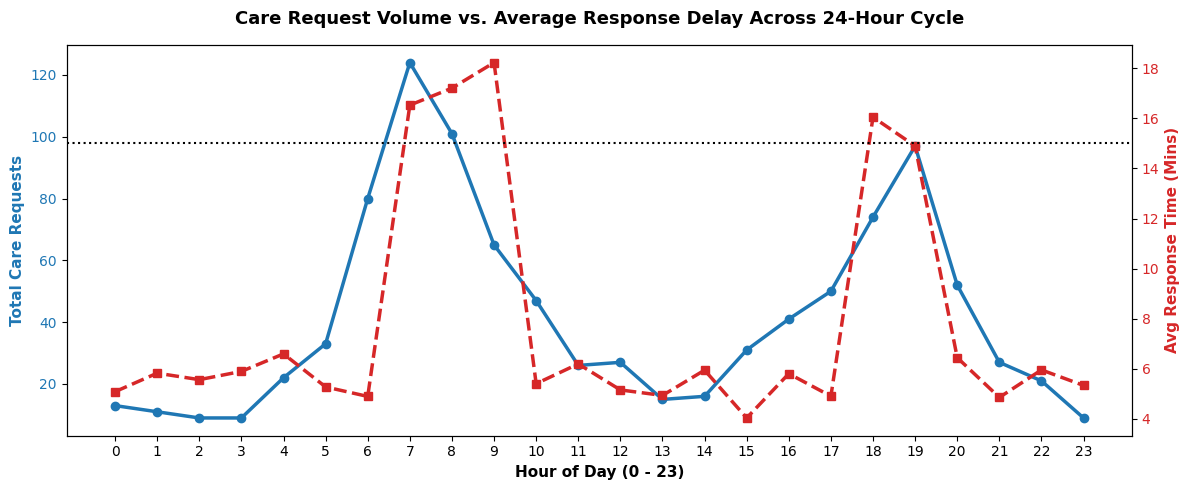

/tmp/ipykernel_4341/1561431368.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=type_summary, x='sla_breach_rate', y='request_type', palette='Reds_r')


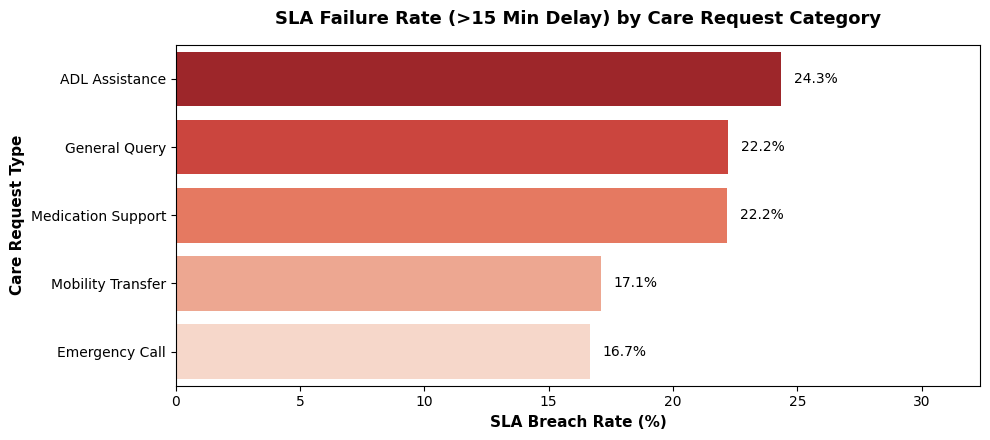

Execution Complete! Both charts saved as PNG images.


In [13]:

# Chart 1: 24-Hour Demand Volume vs Response Delay
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Hour of Day (0 - 23)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Care Requests', color=color, fontsize=11, fontweight='bold')
ax1.plot(hourly_sql_summary['request_hour'],hourly_sql_summary['total_requests'],
         color=color, marker='o', linewidth=2.5, label='Request Volume')
ax1.tick_params(axis='y', labelcolor=color)

# Secondary Y-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Avg Response Time (Mins)', color=color, fontsize=11, fontweight='bold')
ax2.plot(hourly_sql_summary['request_hour'], hourly_sql_summary['avg_response_time_min'],
         color=color, marker='s', linestyle='--', linewidth=2.5, label='Avg Response Time')
ax2.tick_params(axis='y', labelcolor=color)

# SLA Target Line
ax2.axhline(y=15, color='black', linestyle=':', label='SLA Target Threshold (15 min)')

plt.title('Care Request Volume vs. Average Response Delay Across 24-Hour Cycle', fontsize=13, fontweight='bold', pad=15)
plt.xticks(range(0, 24))
fig.tight_layout()
plt.savefig('hourly_demand_vs_response.png', dpi=300)
plt.show()

# Chart 2: SLA Breach Rate by Care Category
plt.figure(figsize=(10, 4.5))
type_summary = clean_df.groupby('request_type')['sla_breach_flag'].mean().reset_index()
type_summary['sla_breach_rate'] = type_summary['sla_breach_flag'] * 100
type_summary = type_summary.sort_values(by='sla_breach_rate', ascending=False)

ax = sns.barplot(data=type_summary, x='sla_breach_rate', y='request_type', palette='Reds_r')
plt.title('SLA Failure Rate (>15 Min Delay) by Care Request Category', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('SLA Breach Rate (%)', fontsize=11, fontweight='bold')
plt.ylabel('Care Request Type', fontsize=11, fontweight='bold')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}%',
                (width + 0.5, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, color='black')

plt.xlim(0, max(type_summary['sla_breach_rate']) + 8)
plt.tight_layout()
plt.savefig('sla_breach_by_care_type.png', dpi=300)
plt.show()

print("Execution Complete! Both charts saved as PNG images.")

**Key Findings**

**1. Predictable Bimodal Demand Surges:**

Care requests are not evenly distributed throughout the day. The highest request volumes occur during the morning period of 7:00–9:00 AM and the evening period of 6:00–7:00 PM. These predictable demand patterns indicate that resident-care activity varies considerably by time of day.

**2. Peak Periods Are Associated With Longer Response Times:**

Response times increase substantially during periods of higher demand. Average response time was 16.50 minutes during peak periods, compared with 5.40 minutes during off-peak periods. Welch’s t-test confirmed that this difference was statistically significant (t = 25.7931, p < 0.001).

**3. ADL Assistance and Mobility Transfers Account for a Large Share of SLA Breaches**

ADL Assistance and Mobility Transfer requests together accounted for 57.80% of all SLA breaches. These request categories may require additional caregiver coordination or assistance. However, the Chi-Square test found no statistically significant association between request type and SLA breach status (χ² = 4.64, p = 0.3264). Therefore, request type should be viewed as an operational consideration rather than a confirmed statistical driver of SLA breaches.

**4. Day of Week Does Not Significantly Affect Response Time**

The one-way ANOVA found no statistically significant difference in response times across days of the week (F = 0.5312, p = 0.7848). This suggests that the more meaningful variation in this dataset occurs by time of day rather than day of week.

**5. Opportunities Exist to Better Align Operations With Demand**

The combination of predictable peak demand and significantly longer response times suggests an opportunity for management to better align existing caregiver activities and coverage with periods of higher resident-care demand. Staggered scheduling, targeted shift overlap, and using lower-demand periods for non-urgent activities could be considered without necessarily increasing total headcount.




**Recommendations:**

Based on the analysis of resident care-request patterns, response times, and SLA performance, the following recommendations are proposed to reduce SLA breaches, improve resident safety, and optimize labor utilization without necessarily increasing total staffing or labor costs.

1. **Align Caregiver Coverage With Peak Demand**

Consider reallocating existing caregiver hours toward the identified high-demand periods, particularly 7:00–9:00 AM and 6:00–7:00 PM. Staggered shifts or targeted shift overlap could provide additional coverage when request volumes are highest.

Expected benefit: Improved response-time performance during peak periods and fewer requests exceeding the 15-minute SLA target, without necessarily increasing total headcount.

**2. Prioritize Coordination for High-Volume Care Activities**

Pay particular attention to ADL Assistance and Mobility Transfer requests, which together accounted for 57.80% of SLA breaches. Where resident needs require additional assistance, appropriate caregiver coordination should be planned during high-demand periods.

Expected benefit: Better preparedness for requests that may require additional caregiver support and improved operational responsiveness.

**3. Use Lower-Demand Periods for Non-Urgent Activities**

Where operationally appropriate, schedule documentation, staff meetings, training, and other non-urgent activities during periods of relatively lower resident-care demand.

Expected benefit: Better alignment of existing staff time with resident-care needs while maintaining current staffing levels.

**4. Monitor Peak-Period Performance**

Continue tracking hourly request volume, average response time, and SLA breach rates to determine whether changes in scheduling and workflow improve performance over time.

Expected benefit: Provides management with measurable evidence for refining caregiver schedules and operational practices based on actual demand patterns.



**Conclusion:**

This analysis demonstrates that resident care requests are not evenly distributed throughout the day. Demand is concentrated during predictable morning and evening periods, particularly 7:00–9:00 AM and 6:00–7:00 PM. These periods also experience substantially longer response times, with average response time increasing from 5.40 minutes during off-peak periods to 16.50 minutes during peak periods.

Welch’s t-test confirmed that the difference between peak and off-peak response times was statistically significant (t = 25.7931, p < 0.001), providing strong evidence that response-time performance varies by time of day.

The analysis also found that ADL Assistance and Mobility Transfer requests accounted for 57.80% of all SLA breaches. However, the Chi-Square test did not identify a statistically significant relationship between request type and SLA breach status. Similarly, the ANOVA found no statistically significant difference in response times across days of the week.

Overall, the findings suggest that time of day is a more important operational consideration than day of week or request category in this dataset. Management can use these predictable demand patterns to consider reallocating existing caregiver hours, using staggered shifts or targeted coverage during peak periods, while utilizing lower-demand periods for non-urgent operational activities.

By aligning available resources more closely with resident-care demand and continuously monitoring response-time and SLA performance, senior-living facilities can identify opportunities to improve timely care delivery without necessarily increasing total staffing or labor costs.


In [17]:
from google.colab import files
files.download('care_requests.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
plt.savefig('hourly_demand_vs_response.png', dpi=300)

<Figure size 640x480 with 0 Axes>

In [18]:
plt.savefig('hourly_demand_vs_response.png', dpi=300)

<Figure size 640x480 with 0 Axes>

In [20]:
from google.colab import files

files.download('hourly_demand_vs_response.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
files.download('sla_breach_by_care_type.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>